In [ ]:
from utils import * 
import subprocess
from files.bam import BamFile 

%load_ext autoreload 
%autoreload 2

# reverse_complement_genome_ids = ['bz_0', 'bz_1', 'bz_4', 'bz_5', 'bz_7', 'bz_8','bz_12']

In [ ]:
# It seems important to assess whether or not genes are contained on the same mRNA fragment, which we should be able to piece together from the metatranscriptomic data. 

sample_metadata_df = pd.read_csv('../data/sr-vp/sample_metadata.csv')
sample_metadata_df = sample_metadata_df[sample_metadata_df.regime == 'MetaT'].copy()

BOWTIE_CMD = 'bowtie2 -x {index_path} -1 {forward_reads_path} -2 {reverse_reads_path} -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > {output_path}'
BOWTIE_REF_PATH = '/home/philippar/bz_0.fasta'
BOWTIE_REF_NAME = os.path.basename(BOWTIE_REF_PATH).replace('.fna', '')
BOWTIE_INDEX_PATH = os.path.join('/home/philippar/bowtie/index/', BOWTIE_REF_NAME)

print(f'bowtie2-build {BOWTIE_REF_PATH} {BOWTIE_INDEX_PATH}') # Only need to build the index once for a given reference. 

for row in sample_metadata_df.itertuples():
    output_path = os.path.join('/home/philippar/bowtie/', f'{row.sample_id}.bam')
    # bowtie2 mapping command for running on biotite. 
    cmd = BOWTIE_CMD.format(index_path=BOWTIE_INDEX_PATH, forward_reads_path=row.forward_reads_path, reverse_reads_path=row.reverse_reads_path, output_path=output_path)
    print(f'sbatch --wrap "{cmd}"')

bowtie2-build /home/philippar/bz_0.fasta /home/philippar/bowtie/index/bz_0.fasta
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/bz_0.fasta -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_06_2024_metaT_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2024_metat.bam"
sbatch --wrap "bowtie2 -x /home/philippar/bowtie/index/bz_0.fasta -1 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT_trim_clean.PE.1.fastq.gz -2 /groups/banfield/sequences/2025/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT/raw.d/SR-VP_Bioreactor_ck_bot_05_17_2025_metaT_trim_clean.PE.2.fastq.gz -p 20 -X 1000  | shrinksam | samtools sort -@ 4 -l 6 > /home/philippar/bowtie/ch4_bottom_2

In [ ]:
genes_df = pd.read_csv('../data/genes/genes.csv', index_col=0)
genes_df['gene_id'] = genes_df.index
genes_df['cluster_id'] = genes_df.index.map(json.load(open('../data/genes/clusters.json', 'r')))
genes_df = genes_df[genes_df.genome_id == 'bz_0'].copy()

supported_gene_ids = np.loadtxt('analysis-1-cluster-supported_gene_ids.txt', dtype=str)
genes_df = genes_df[genes_df.gene_id.isin(supported_gene_ids)].copy()

# genes_df[~genes_df.prodigal_gene_id.isnull()].sort_values('start')

# for row in genes_df.itertuples():
#     genes_df.loc[row.Index, 'start'] = row.genome_size - (row.stop + 1)
#     genes_df.loc[row.Index, 'stop'] = row.genome_size - (row.start - 1) 
#     genes_df.loc[row.Index, 'strand'] = '+' if (row.strand == '-') else '-'


In [60]:
figure_df

,read_id,flag,ref_id,position,mapping_quality,cigar,mate_ref_id,mate_position,template_length,seq,...,=,S,H,n_errors,n_clips,ref_alignment_length,read_alignment_length,left_clip_length,right_clip_length,mapped
0,VH00771:209:AACWGGFHV:2:1204:8404:33733,163,bz_0,2,0,5M17I128M,=,77,225,CTATACTACTATACTACTATACTACTACACTTCCACCACTCAGACA...,...,0,0,0,17,0,0,17,0,0,1
1,VH00771:209:AACWGGFHV:2:1203:29422:38201,163,bz_0,9,1,4M3I3M2I138M,=,64,205,CTACTATACTACTATACCACTCAGACACTCTATAAATTCCCATCTG...,...,0,0,0,5,0,0,5,0,0,1
2,VH00771:209:AACWGGFHV:2:1403:40405:39753,163,bz_0,9,1,4M3I3M2I138M,=,64,205,CTACTATACTACTATACCACTCAGACACTCTATAAATTCCCATCTG...,...,0,0,0,5,0,0,5,0,0,1
3,VH00771:209:AACWGGFHV:2:1411:11206:33279,163,bz_0,9,1,7M1I142M,=,420,561,CTATCTTATCCACCACTCAGACACTCTATAAATTCCCATCTGAAGT...,...,0,0,0,1,0,0,1,0,0,1
4,VH00771:209:AACWGGFHV:2:1209:68694:42783,163,bz_0,10,1,6M4I115M,=,422,562,TGCTATCTTATCCACCACTCAGACACTCTATAAATTCCCATCTGAA...,...,0,0,0,4,0,0,4,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,VH00771:209:AACWGGFHV:1:2311:36390:48273,147,bz_0,18277,42,150M,=,18271,-156,TACTTCAAGCCTTGTGGGTTCATATCCGCCCGTTGCATCGAAATCT...,...,0,0,0,0,0,0,0,0,0,1
74,VH00771:209:AACWGGFHV:2:2510:57049:36933,163,bz_0,18548,1,150M,=,18608,210,AGACCACACCTTTGTATTTGAAGCCGTGCTTTACATCATTCTTTGA...,...,0,0,0,0,0,0,0,0,0,1
75,VH00771:209:AACWGGFHV:2:2510:57049:36933,83,bz_0,18608,1,150M,=,18548,-210,AAATTTCATCACCTGATAATAAAATCTGTTCTGTTTTTGTTATATT...,...,0,0,0,0,0,0,0,0,0,1
76,VH00771:209:AACWGGFHV:1:2404:27680:37103,99,bz_0,18847,1,150M,=,18871,174,CAGTTTCGTTAATAAATTTATGAAGTGGACTGTGTAAAAATATGTA...,...,0,0,0,0,0,0,0,0,0,1


In [43]:
level_1_conserved_cluster_ids = [8, 7, 0, 4, 5, 6, 1, 3, 2]
level_2_conserved_cluster_ids = [9, 12, 10, 13, 11]
level_3_conserved_cluster_ids = [18, 42, 33, 25, 17, 19, 20, 21, 50, 31, 40, 27, 34, 15, 14, 54, 24, 23, 41, 39, 57, 47, 48, 51, 45, 35, 49, 28, 62, 29]

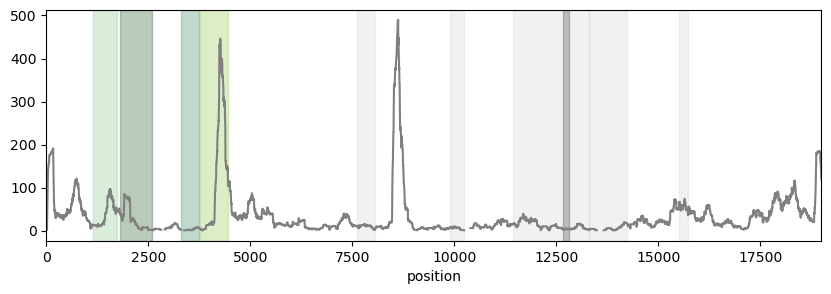

In [59]:
# Want to look at the coverage profile of the transcripts. 

def plot_mapping(figure_df, func=np.sum, metric:str='mapped', ax=None, label=None, max_nm=5, read_length=150):
    '''Plot the coverage of a reference sequence by mapped reads in a BAM file.'''

    figure_df['mapped'] = (~figure_df.unmapped).astype(int)
    figure_df = figure_df[figure_df.NM <= max_nm].copy()

    ref_length = figure_df.ref_length.iloc[0]
    positions = np.arange(ref_length)
    values = np.zeros((len(figure_df), len(positions)))

    for i, row in enumerate(figure_df.itertuples()):
        start = row.position
        stop = min(start + 150, ref_length)
        values[i, start:stop] = getattr(row, metric)

    values = func(values, axis=0)
    values = np.where(values == 0, np.nan, values) # Set the value to NaN where there is no coverage so it is clearer on the graph. 
    ax.plot(positions, values, label=label, color='gray')
    ax.set_xlabel('position')

    stats = dict()
    stats['coverage'] = (read_length * len(figure_df)) / ref_length
    stats['variance'] = np.var(values)
    stats['coefficient_of_variance'] = np.sqrt(stats['variance']) / stats['coverage']
    stats['read_count'] = figure_df.mapped.sum()
    stats['fraction_covered'] = (values > 0).mean()
    return stats


paths = glob.glob('../data/genes/bowtie/*bam')
for path in paths:
    # Need an index file in order to read mappings to a specified ref_id.
    if not os.path.exists(path + '.bai'):
        subprocess.run(f'samtools index {path}', shell=True, check=True)

figure_df = pd.concat([BamFile.from_file(path).to_df() for path in paths])

x_min = 0
x_max = 19000


palette = dict()
palette = {cluster_id:'lightgray' for cluster_id in genes_df.cluster_id.unique()}
# palette.update({cluster_id:'gray' for cluster_id in level_2_conserved_cluster_ids})
# palette.update({cluster_id:'black' for cluster_id in level_1_conserved_cluster_ids})
# palette.update({cluster_id:'gray' for cluster_id in level_3_conserved_cluster_ids})
palette.update({1:"#2B8756", 3:"#1C531E", 2:"#86C589", 6:"#91C449", 17:'black'})

fig, ax = plt.subplots(figsize=(10, 3))
plot_mapping(figure_df, ax=ax)

for row in genes_df.itertuples():
    if row.cluster_id in level_1_conserved_cluster_ids + [17]:
        ax.axvspan(row.start, row.stop, alpha=0.3, color=palette[int(row.cluster_id)], label=f'cluster {int(row.cluster_id)}')

# ax.legend(loc='upper left')
ax.set_xlim(xmin=x_min, xmax=x_max)

# ax.axvline(276, ls='--', color='black')
# ax.axvline(821, ls='--', color='black')
plt.show()
    

In [48]:
genes_df[~genes_df.prodigal_gene_id.isnull()].sort_values('start', ascending=False)

,nt_seq,description,seq,frame,gene_number,start,stop,strand,partial,has_start_codon,...,prodigal_length_from_start_codon,prodigal_partial,prodigal_gene_id,prodigal_start_idx,genome_size,seq_untrimmed,nt_seq_untrimmed,num_residues_trimmed,gene_id,cluster_id
gene_id,,,,,,,,,,,,,,,,,,,,,
orfm.bz_0.1_213,TTGAGTAATAAGATGAAAGAAATTAAGAAAGTAACTTCAATAAAGG...,NaN,LSNKMKEIKKVTSIKVYPSLINRAKIKAVEQGITLSELIEKAIDNI...,6,213,18474,18805,-,False,True,...,99.0,False,prodigal.bz_0.1_38,3.0,19040,YSSIVVLSNKMKEIKKVTSIKVYPSLINRAKIKAVEQGITLSELIE...,TATAGTAGTATAGTAGTATTGAGTAATAAGATGAAAGAAATTAAGA...,6,orfm.bz_0.1_213,60.0
orfm.bz_0.1_208,ATGATACAAATGAGTGAAATAAGAAATAAGTATAATGGAAAGACAA...,NaN,MIQMSEIRNKYNGKTIRIQRNIYTITVRDFDATGGYEPTRLEVILT...,4,208,18118,18434,-,False,True,...,92.0,False,prodigal.bz_0.1_37,2.0,19040,RLSAYNIKGMIQMSEIRNKYNGKTIRIQRNIYTITVRDFDATGGYE...,CGGTTATCCGCATATAACATAAAAGGAATGATACAAATGAGTGAAA...,9,orfm.bz_0.1_208,1324.0
orfm.bz_0.1_198,ATGCATATCTCATTTTACAAAATAGATTCTTTTTTAAGTAATATGC...,NaN,MHISFYKIDSFLSNMLKEDYYYLISMSVYHIELITFGLLGLIPVWY...,3,198,17307,17905,+,False,True,...,197.0,False,prodigal.bz_0.1_36,-1.0,19040,NMHISFYKIDSFLSNMLKEDYYYLISMSVYHIELITFGLLGLIPVW...,AATATGCATATCTCATTTTACAAAATAGATTCTTTTTTAAGTAATA...,1,orfm.bz_0.1_198,2.0
orfm.bz_0.1_191,TTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAAAGGAAA...,NaN,LRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLTLM...,2,191,16451,17241,+,False,True,...,257.0,False,prodigal.bz_0.1_35,2.0,19040,KSLRTLRLCGENVQEKEILELILSRYVCFVGGRYSRGKSLILTFLT...,AAATCTTTGCGAACTTTGCGTCTTTGCGGTGAAAACGTGCAAGAAA...,2,orfm.bz_0.1_191,3.0
orfm.bz_0.1_184,ATGGATAAAATGAATGATGCAGATATAGTAAAAGCAATAAAAGCAT...,NaN,MDKMNDADIVKAIKALGILFLFLLGMASGADYSDNNWKHDIIKVSD...,2,184,16166,16455,+,False,True,...,92.0,False,prodigal.bz_0.1_34,-1.0,19040,ENKMDKMNDADIVKAIKALGILFLFLLGMASGADYSDNNWKHDIIK...,GAAAATAAGATGGATAAAATGAATGATGCAGATATAGTAAAAGCAA...,3,orfm.bz_0.1_184,1340.0
orfm.bz_0.1_180,GTGATAGATTTGCCTGAATGGTTAGTAAAATCAACATTAAGAGAAC...,NaN,VIDLPEWLVKSTLRELDRIDKEHESGKISDSEHIKQSKKVIEKALS...,1,180,15922,16178,+,False,True,...,84.0,False,prodigal.bz_0.1_33,-1.0,19040,VIDLPEWLVKSTLRELDRIDKEHESGKISDSEHIKQSKKVIEKALS...,GTGATAGATTTGCCTGAATGGTTAGTAAAATCAACATTAAGAGAAC...,0,orfm.bz_0.1_180,1343.0
orfm.bz_0.1_178,ATGTTGACATATATAAAATTTAAATGCCCAAACAATGATGAAATAT...,NaN,MLTYIKFKCPNNDEIYEIEYNGTVKDFLDEYPDRNILDSHCMQSNP...,3,178,15747,15943,+,False,True,...,62.0,False,prodigal.bz_0.1_32,-1.0,19040,NEMLTYIKFKCPNNDEIYEIEYNGTVKDFLDEYPDRNILDSHCMQS...,AACGAAATGTTGACATATATAAAATTTAAATGCCCAAACAATGATG...,2,orfm.bz_0.1_178,1345.0
orfm.bz_0.1_175,ATGAGTAAAGAAAAAGAATCATTAGAAAATGAAACAGGATTTAGTG...,NaN,MSKEKESLENETGFSEKQTAFITNLFTGKGGIFDRPQGQGGDATND...,3,175,15288,15751,+,False,True,...,150.0,False,prodigal.bz_0.1_31,-1.0,19040,SDKMSKEKESLENETGFSEKQTAFITNLFTGKGGIFDRPQGQGGDA...,AGTGATAAAATGAGTAAAGAAAAAGAATCATTAGAAAATGAAACAG...,3,orfm.bz_0.1_175,1.0
orfm.bz_0.1_169,ATGTGGAATCCATTTAAAACTTTAACTAAAAATGCCCCGACTATAA...,NaN,MWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMDLN...,1,169,14590,15284,+,False,True,...,228.0,False,prodigal.bz_0.1_30,-1.0,19040,LIMWNPFKTLTKNAPTIKDISRIPSDIKDSAYNIKANKITIRYFMD...,TTAATTATGTGGAATCCATTTAAAACTTTAACTAAAAATGCCCCGA...,2,orfm.bz_0.1_169,6.0
